In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd 
import seaborn as sns 
import math
import random
from scipy.integrate import simps
from sklearn.manifold import TSNE
from scipy.integrate import simps
from scipy import stats
from datetime import datetime
from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from statannotations.Annotator import Annotator
import scipy.signal
from scipy.stats import exponnorm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from lmfit.models import GaussianModel
from lmfit.models import GaussianModel,ExponentialGaussianModel,SkewedGaussianModel,VoigtModel,LorentzianModel,LognormalModel
from scipy.signal import savgol_filter, find_peaks, find_peaks_cwt
from scipy import sparse
from scipy.sparse.linalg import spsolve
import scipy
import pybaselines


plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams["font.family"] = "Arial"
sns.set(font_scale=2.5)
sns.set_style("ticks")
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
g4=pd.read_excel("Fig4G_quant.xlsx")
g4["% triglycerides of total hepatic lipids"]=g4["Fraction of Total Lipid Content"]*100

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT vs. asgr1a$^{c830/c830}$: Mann-Whitney-Wilcoxon test two-sided, P_val:7.898e-03 U_stat=6.300e+01
WT vs. asgr1a$^{c865/c865}$: Mann-Whitney-Wilcoxon test two-sided, P_val:3.702e-03 U_stat=6.500e+01


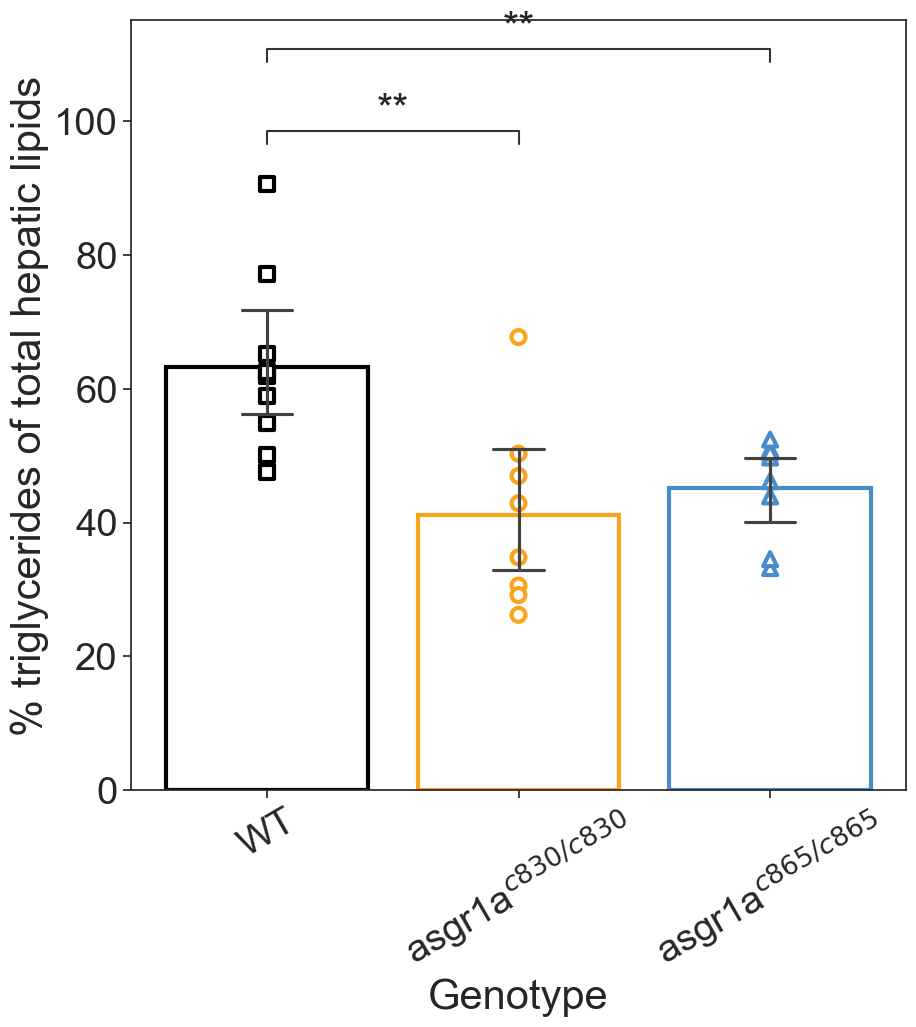

In [3]:
fig,ax=plt.subplots(figsize=(10,10))
plt.style.use('fast')
sns.barplot(data=g4,x="Genotype",y="% triglycerides of total hepatic lipids",ax=ax,edgecolor=["Black","#FAA31B","#488CCB"], facecolor="white",linewidth=3,capsize=0.2)
sns.scatterplot(data=g4,x="Genotype",hue="Genotype",y="% triglycerides of total hepatic lipids",palette=["Black","#FAA31B","#488CCB"],linewidth=3,ax=ax,legend=False,s=100,style="Genotype",markers=["s","o","^"])
ax.set_ylim(0,100)

for coll in ax.collections:
    color = coll.get_facecolor()
    coll.set_edgecolor(color)
    coll.set_facecolor("white")
pairs=[("WT","asgr1a$^{c830/c830}$"),("WT","asgr1a$^{c865/c865}$")]
annotator = Annotator(ax,pairs, data=g4, x="Genotype", y="% triglycerides of total hepatic lipids")
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()



plt.xticks(rotation=30)
ax.set_ylim(0,115)
#plt.savefig("4G.svg")
plt.show()

In [4]:
I4=pd.read_excel("Fig4I_quant.xlsx")
I4["% cholesterol of total fecal lipids"]=I4["Fraction of Total Lipid Content"]*100

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT vs. asgr1a$^{c830/c830}$: Mann-Whitney-Wilcoxon test two-sided, P_val:1.554e-03 U_stat=0.000e+00
WT vs. asgr1a$^{c865/c865}$: Mann-Whitney-Wilcoxon test two-sided, P_val:4.329e-03 U_stat=0.000e+00


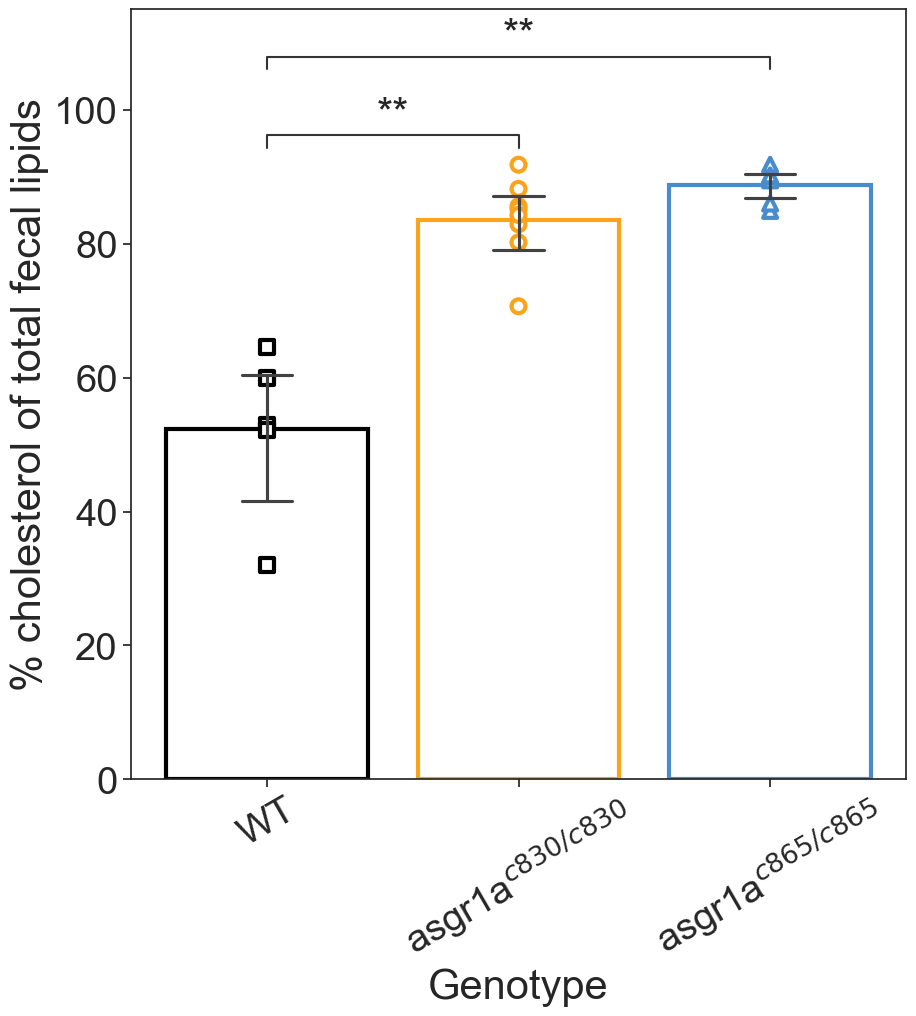

In [5]:
fig,ax=plt.subplots(figsize=(10,10))
plt.style.use('fast')
sns.barplot(data=I4,x="Genotype",y="% cholesterol of total fecal lipids",ax=ax,edgecolor=["Black","#FAA31B","#488CCB"], facecolor="white",linewidth=3,capsize=0.2)
sns.scatterplot(data=I4,x="Genotype",hue="Genotype",y="% cholesterol of total fecal lipids",palette=["Black","#FAA31B","#488CCB"],linewidth=3,ax=ax,legend=False,s=100,style="Genotype",markers=["s","o","^"])
for coll in ax.collections:
    color = coll.get_facecolor()
    coll.set_edgecolor(color)
    coll.set_facecolor("white")
pairs=[("WT","asgr1a$^{c830/c830}$"),("WT","asgr1a$^{c865/c865}$")]
annotator = Annotator(ax,pairs, data=I4, x="Genotype", y="Fraction of Total Lipid Content")
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
plt.xticks(rotation=30)
ax.set_ylim(0,115)
#plt.savefig("4I.svg")
plt.show()

In [6]:
supp5h=pd.read_excel("FigSupp5H.xlsx")
supp5h["% triglycerides of total hepatic lipids"]=supp5h["Fraction of Total Lipid Content"]*100

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT vs. $asgr1a^{c830/c830}$: Mann-Whitney-Wilcoxon test two-sided, P_val:4.000e-01 U_stat=2.000e+00
WT vs. $asgr1a^{c865/c865}$: Mann-Whitney-Wilcoxon test two-sided, P_val:7.000e-01 U_stat=3.000e+00


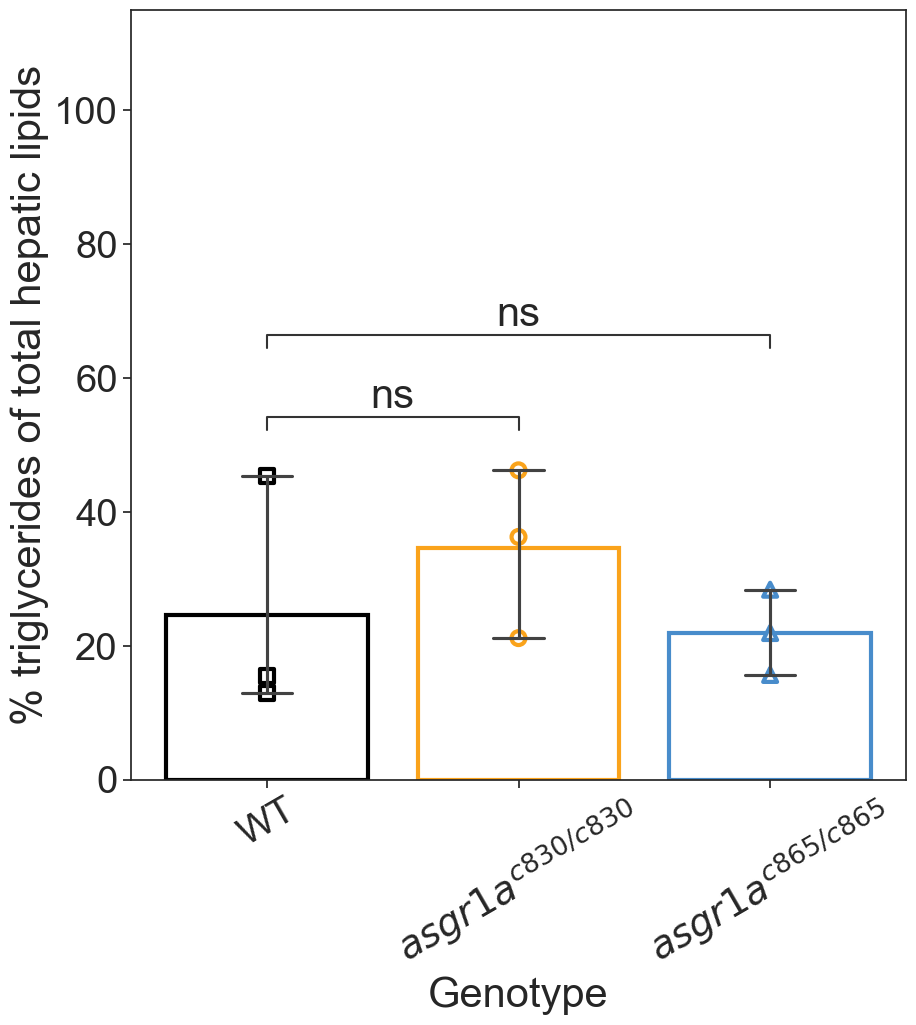

In [7]:
fig,ax=plt.subplots(figsize=(10,10))
plt.style.use('fast')
sns.barplot(data=supp5h,x="Genotype",y="% triglycerides of total hepatic lipids",ax=ax,edgecolor=["Black","#FAA31B","#488CCB"], facecolor="white",linewidth=3,capsize=0.2)
sns.scatterplot(data=supp5h,x="Genotype",hue="Genotype",y="% triglycerides of total hepatic lipids",palette=["Black","#FAA31B","#488CCB"],linewidth=3,ax=ax,legend=False,s=100,style="Genotype",markers=["s","o","^"])
ax.set_ylim(0,100)

for coll in ax.collections:
    color = coll.get_facecolor()
    coll.set_edgecolor(color)
    coll.set_facecolor("white")
pairs=[("WT","$asgr1a^{c830/c830}$"),("WT","$asgr1a^{c865/c865}$")]
annotator = Annotator(ax,pairs, data=supp5h, x="Genotype", y="% triglycerides of total hepatic lipids")
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()



plt.xticks(rotation=30)
ax.set_ylim(0,115)
#plt.savefig("supp5H.svg")
plt.show()